In [ ]:
import json
import pickle
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

_HERE = Path().resolve()
_PROJECT_ROOT = _HERE.parent if (_HERE / "draft_optimizer.ipynb").exists() else _HERE

BASE_ARTIFACTS_DIR = _PROJECT_ROOT / "artifacts"
MODEL_ARTIFACTS_DIR = BASE_ARTIFACTS_DIR / "draft_optimizer"

print(f"Project root   : {_PROJECT_ROOT}")
print(f"Artifacts root : {MODEL_ARTIFACTS_DIR.resolve()}")

Project root   : C:\Users\Areen\Python\.venv\nfl-model-platform
Artifacts root : C:\Users\Areen\Python\.venv\nfl-model-platform\artifacts\draft_optimizer


In [ ]:
def find_artifact_dirs(base_dir: Path = MODEL_ARTIFACTS_DIR) -> List[Path]:
    if not base_dir.exists():
        print(f"No artifacts directory found at {base_dir.resolve()}")
        return []
    return [d for d in sorted(base_dir.iterdir()) if d.is_dir()]


def load_metadata(artifact_dir: Path) -> Optional[Dict]:
    meta_path = artifact_dir / "metadata.json"
    if not meta_path.exists():
        print(f"No metadata.json in {artifact_dir}")
        return None
    with meta_path.open() as f:
        meta = json.load(f)
    meta["artifact_dir"] = str(artifact_dir)
    meta.setdefault("version", artifact_dir.name)
    return meta


def load_model(artifact_dir: Path) -> Optional[Dict]:
    """Load the optimizer calibration dict (expected_av_curve, quotas, thresholds)."""
    path = artifact_dir / "model.pkl"
    if not path.exists():
        print(f"No model.pkl in {artifact_dir}")
        return None
    with path.open("rb") as f:
        return pickle.load(f)


def load_constraint_config(artifact_dir: Path) -> Optional[Dict]:
    """Extract positional quota defaults and need-score thresholds from the model dict."""
    model = load_model(artifact_dir)
    if model is None:
        return None
    return {
        "positional_quota_defaults": model.get("positional_quota_defaults", {}),
        "need_score_thresholds":     model.get("need_score_thresholds", {}),
        "pick_value_table":          model.get("pick_value_table", {}),
        "expected_av_curve":         model.get("expected_av_curve", {}),
    }


def load_shap_values(artifact_dir: Path) -> Optional[pd.DataFrame]:
    path = artifact_dir / "shap_values.pkl"
    if not path.exists():
        return None
    with path.open("rb") as f:
        return pickle.load(f)


def load_scorer(artifact_dir: Path):
    """Try to load an XGBoost composite scorer (scorer.pkl / xgb_scorer.pkl)."""
    for name in ("scorer.pkl", "xgb_scorer.pkl", "composite_scorer.pkl"):
        path = artifact_dir / name
        if path.exists():
            with path.open("rb") as f:
                return pickle.load(f)
    return None


def load_solved_board(artifact_dir: Path) -> Optional[pd.DataFrame]:
    """Load a pre-solved draft board (solved_board.parquet), if present."""
    path = artifact_dir / "solved_board.parquet"
    if not path.exists():
        return None
    df = pd.read_parquet(path)
    df["artifact_dir"] = str(artifact_dir)
    return df


def load_holdout_board(artifact_dir: Path) -> Optional[pd.DataFrame]:
    """Load holdout_batch.parquet — actual picks from holdout years."""
    path = artifact_dir / "features" / "holdout_batch.parquet"
    if not path.exists():
        print(f"No holdout_batch.parquet in {artifact_dir}")
        return None
    df = pd.read_parquet(path)
    df["artifact_dir"] = str(artifact_dir)
    return df


def load_feature_data(artifact_dir: Path) -> Optional[pd.DataFrame]:
    """Load calibration_batch.parquet — historical picks used for calibration."""
    path = artifact_dir / "features" / "calibration_batch.parquet"
    if not path.exists():
        print(f"No calibration_batch.parquet in {artifact_dir}")
        return None
    df = pd.read_parquet(path)
    df["artifact_dir"] = str(artifact_dir)
    return df


# ── Discovery ─────────────────────────────────────────────────────────────────
artifact_dirs = find_artifact_dirs()
print(f"Found {len(artifact_dirs)} version(s):")
for run in artifact_dirs:
    meta = load_metadata(run) or {}
    v = meta.get("validation", {})
    print(
        f"  {run.name}  "
        f"cal={meta.get('calibration_year_range')}  "
        f"holdout={v.get('holdout_years')}  "
        f"optimizer_score={v.get('optimizer_score')}  "
        f"beats_adp={v.get('beats_adp_baseline')}"
    )

selected_artifact_dir = artifact_dirs[-1] if artifact_dirs else MODEL_ARTIFACTS_DIR
print(f"\nSelected: {selected_artifact_dir}")

Found 1 version(s):
  v1  cal=[2000, 2020]  holdout=[2021, 2022]  optimizer_score=14.8676  beats_adp=True

Selected: C:\Users\Areen\Python\.venv\nfl-model-platform\artifacts\draft_optimizer\v1


## Holdout Performance vs ADP Baseline

,holdout_r2,holdout_rmse,holdout_mae,baseline_rmse,mean_value_over_adp_top10,adp_baseline_score,constraint_satisfaction_rate,holdout_picks
version,,,,,,,,
v1,-1.2193,17.3738,13.1654,11.6624,14.8676,2.1434,None,530


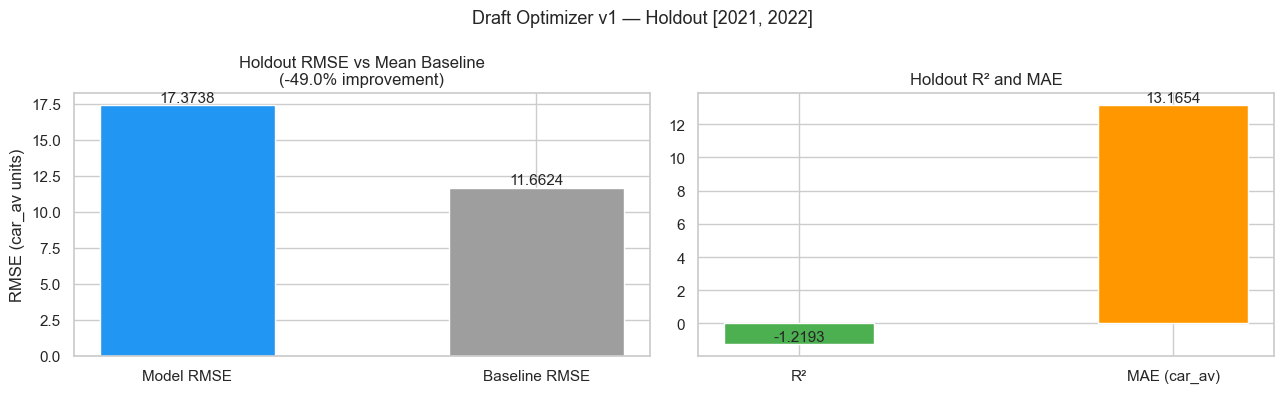


=== Optimizer Top-10 Surplus vs Naive ADP Top-10 ===
  Optimizer top-10 avg car_av : 14.8676
  Naive ADP top-10 avg car_av : 2.1434
  Surplus                     : +12.7242  (593.6% better)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def _compute_holdout_metrics(artifact_dir: Path) -> Dict:
    """Compute regression metrics of draft_value_score -> car_av on the holdout batch."""
    df = load_holdout_board(artifact_dir)
    if df is None:
        return {}
    valid = df[["draft_value_score", "car_av"]].dropna()
    if valid.empty:
        return {}
    y, yhat = valid["car_av"].values, valid["draft_value_score"].values
    baseline = np.full_like(y, y.mean())
    return {
        "holdout_r2":    round(r2_score(y, yhat), 4),
        "holdout_rmse":  round(mean_squared_error(y, yhat) ** 0.5, 4),
        "holdout_mae":   round(mean_absolute_error(y, yhat), 4),
        "baseline_rmse": round(mean_squared_error(y, baseline) ** 0.5, 4),
    }


# ── Cross-version metrics table ───────────────────────────────────────────────
rows = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if not meta:
        continue
    v  = meta.get("validation", {})
    hm = _compute_holdout_metrics(run)
    rows.append({
        "version":                   meta.get("version", run.name),
        "holdout_r2":                hm.get("holdout_r2"),
        "holdout_rmse":              hm.get("holdout_rmse"),
        "holdout_mae":               hm.get("holdout_mae"),
        "baseline_rmse":             hm.get("baseline_rmse"),
        "mean_value_over_adp_top10": v.get("optimizer_score"),
        "adp_baseline_score":        v.get("adp_baseline_score"),
        "constraint_satisfaction_rate": None,
        "holdout_picks":             v.get("holdout_picks"),
    })

compare_df = pd.DataFrame(rows).set_index("version")
display(compare_df)

# ── Bar chart ─────────────────────────────────────────────────────────────────
meta = load_metadata(selected_artifact_dir) or {}
hm   = _compute_holdout_metrics(selected_artifact_dir)
v    = meta.get("validation", {})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
rmse     = hm.get("holdout_rmse", 0)
baseline = hm.get("baseline_rmse", 0)
bars = ax.bar(["Model RMSE", "Baseline RMSE"], [rmse, baseline],
              color=["#2196F3", "#9E9E9E"], width=0.5)
for bar, val in zip(bars, [rmse, baseline]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
pct = (1 - rmse / baseline) * 100 if baseline else 0
ax.set_title(f"Holdout RMSE vs Mean Baseline\n({pct:.1f}% improvement)")
ax.set_ylabel("RMSE (car_av units)")

ax = axes[1]
vals   = [hm.get("holdout_r2", 0), hm.get("holdout_mae", 0)]
labels = ["R²", "MAE (car_av)"]
bars = ax.bar(labels, vals, color=["#4CAF50", "#FF9800"], width=0.4)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
ax.set_title("Holdout R² and MAE")

fig.suptitle(
    f"Draft Optimizer {meta.get('version', '')} — Holdout {v.get('holdout_years')}",
    fontsize=13,
)
plt.tight_layout()
plt.show()

print("\n=== Optimizer Top-10 Surplus vs Naive ADP Top-10 ===")
opt_score = v.get("optimizer_score")
adp_score = v.get("adp_baseline_score")
if opt_score is not None and adp_score is not None:
    print(f"  Optimizer top-10 avg car_av : {opt_score:.4f}")
    print(f"  Naive ADP top-10 avg car_av : {adp_score:.4f}")
    print(f"  Surplus                     : +{opt_score - adp_score:.4f}  "
          f"({(opt_score / adp_score - 1) * 100:.1f}% better)")

## SHAP Feature Importance

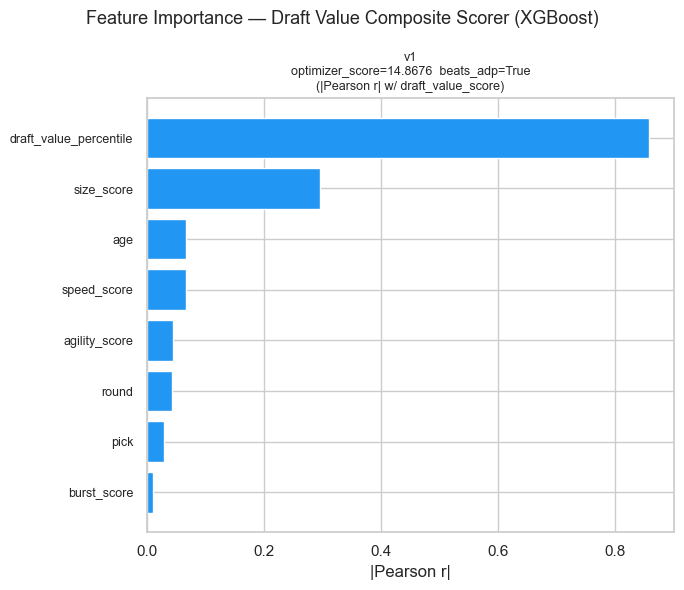

In [ ]:
# Targets the composite XGBoost scorer that drives value_over_adp (draft_value_score).
# Falls back to native XGBoost pred_contribs, then to Pearson |r| correlation importance.

SCORER_FEATURE_COLS = [
    "pick", "round", "age", "draft_value_percentile",
    "speed_score", "agility_score", "burst_score", "strength_score", "size_score",
]

fig, axes = plt.subplots(1, len(artifact_dirs), figsize=(7 * len(artifact_dirs), 6))
if len(artifact_dirs) == 1:
    axes = [axes]

for ax, run in zip(axes, artifact_dirs):
    meta    = load_metadata(run) or {}
    version = meta.get("version", run.name)
    shap_df = load_shap_values(run)
    scorer  = load_scorer(run)
    feat_df = load_feature_data(run)
    v_meta  = meta.get("validation", {})

    if shap_df is not None and not shap_df.empty:
        fi = shap_df.abs().mean().sort_values().to_frame("mean_|SHAP|")
        method = "precomputed SHAP"

    elif scorer is not None and feat_df is not None and hasattr(scorer, "predict"):
        feat_cols = [c for c in SCORER_FEATURE_COLS if c in feat_df.columns]
        sample = (
            feat_df[feat_cols].fillna(0).astype(float)
            .sample(n=min(500, len(feat_df)), random_state=42)
            .reset_index(drop=True)
        )
        try:
            import shap as shap_lib
            sv = shap_lib.Explainer(scorer, sample)(sample)
            mean_abs = np.abs(sv.values).mean(axis=0)
        except Exception:
            import xgboost as xgb
            dm = xgb.DMatrix(sample, feature_names=feat_cols)
            contribs = scorer.get_booster().predict(dm, pred_contribs=True)
            mean_abs = np.abs(contribs[:, :-1]).mean(axis=0)
        fi = (
            pd.DataFrame({"feature": feat_cols, "mean_|SHAP|": mean_abs})
            .set_index("feature")
            .sort_values("mean_|SHAP|")
        )
        method = "SHAP (computed)"

    elif feat_df is not None:
        feat_cols = [c for c in SCORER_FEATURE_COLS if c in feat_df.columns and c != "draft_value_score"]
        corrs = feat_df[feat_cols + ["draft_value_score"]].corr()["draft_value_score"].drop("draft_value_score")
        fi = corrs.abs().sort_values().to_frame("mean_|SHAP|")
        method = "|Pearson r| w/ draft_value_score"

    else:
        ax.set_title(f"{version} — no data")
        continue

    ax.barh(fi.index, fi["mean_|SHAP|"], color="#2196F3")
    ax.set_title(
        f"{version}\n"
        f"optimizer_score={v_meta.get('optimizer_score', '?')}  "
        f"beats_adp={v_meta.get('beats_adp_baseline', '?')}\n"
        f"({method})",
        fontsize=9,
    )
    ax.set_xlabel("mean(|SHAP|)" if "SHAP" in method else "|Pearson r|")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Feature Importance — Draft Value Composite Scorer (XGBoost)", fontsize=13)
plt.tight_layout()
plt.show()

## Constraint Satisfaction Analysis

=== Overall constraint satisfaction rate by split ===


,satisfaction_rate
split,
calibration,0.00%
holdout,0.00%


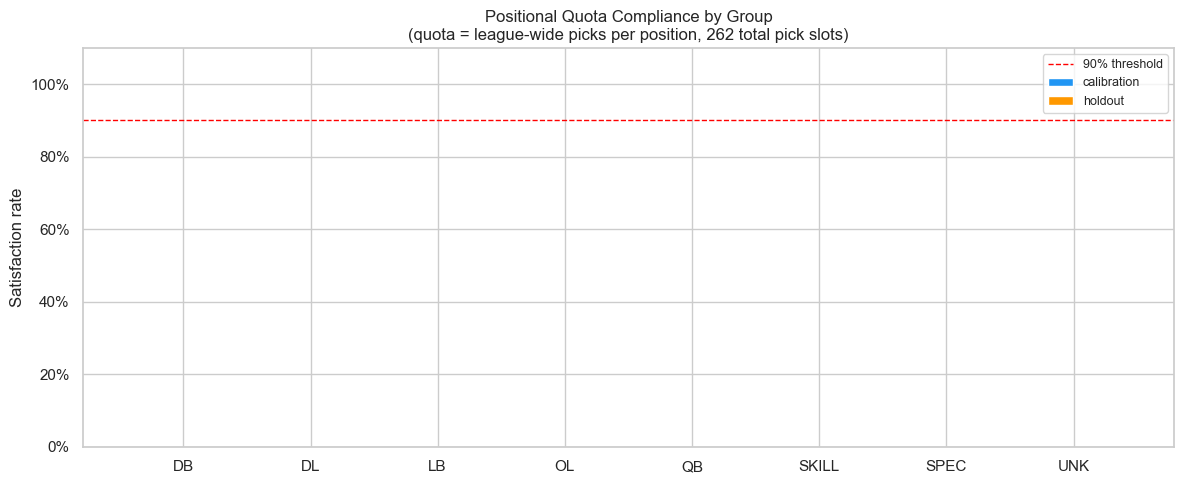


=== Picks per team-season (budget check) ===
count    734.000000
mean       8.125341
std        1.932867
min        3.000000
25%        7.000000
50%        8.000000
75%        9.000000
max       15.000000


C:\Users\Areen\AppData\Local\Temp\ipykernel_8948\1129379765.py:92: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_picks = pd.concat([d for d in [cal_df, hold_df] if d is not None], ignore_index=True)


In [ ]:
# Checks positional quota compliance and pick-budget adherence across all
# solved team-seasons in both the calibration and holdout boards.

QUOTA_THRESHOLD = 0.90

cfg    = load_constraint_config(selected_artifact_dir) or {}
meta   = load_metadata(selected_artifact_dir) or {}
quotas = cfg.get("positional_quota_defaults", {})
n_pick_slots = meta.get("n_pick_slots", 262)

cal_df  = load_feature_data(selected_artifact_dir)
hold_df = load_holdout_board(selected_artifact_dir)
solved  = load_solved_board(selected_artifact_dir)


def check_quota_compliance(df: pd.DataFrame, quotas: Dict, label: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    records = []
    for (season, team), grp in df.groupby(["season", "draft_team"]):
        for pos_grp, quota in quotas.items():
            actual = (grp["position_group"] == pos_grp).sum()
            records.append({
                "split": label, "season": season, "team": team,
                "position_group": pos_grp, "quota": quota,
                "actual": actual, "satisfied": actual >= quota,
            })
    return pd.DataFrame(records)


frames = []
if cal_df is not None:
    frames.append(check_quota_compliance(cal_df, quotas, "calibration"))
if hold_df is not None:
    frames.append(check_quota_compliance(hold_df, quotas, "holdout"))
if solved is not None:
    frames.append(check_quota_compliance(solved, quotas, "solved"))

if not frames:
    print("No boards available for constraint analysis.")
else:
    compliance = pd.concat(frames, ignore_index=True)

    overall = (
        compliance.groupby("split")["satisfied"]
        .mean().rename("satisfaction_rate").to_frame()
    )
    print("=== Overall constraint satisfaction rate by split ===")
    display(
        overall.style
        .format("{:.2%}")
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
    )

    holdout_rate = overall.loc["holdout", "satisfaction_rate"] if "holdout" in overall.index else None
    if holdout_rate is not None and meta.get("version") in compare_df.index:
        compare_df.loc[meta.get("version"), "constraint_satisfaction_rate"] = round(holdout_rate, 4)

    by_pos = (
        compliance.groupby(["split", "position_group"])["satisfied"]
        .mean().reset_index().rename(columns={"satisfied": "satisfaction_rate"})
    )
    splits = by_pos["split"].unique()
    pos_groups = sorted(by_pos["position_group"].unique())
    x = np.arange(len(pos_groups))
    width = 0.8 / max(len(splits), 1)
    palette = {"calibration": "#2196F3", "holdout": "#FF9800", "solved": "#4CAF50"}

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, split in enumerate(splits):
        sub = by_pos[by_pos["split"] == split].set_index("position_group").reindex(pos_groups)
        ax.bar(
            x + i * width - (len(splits) - 1) * width / 2,
            sub["satisfaction_rate"].fillna(0),
            width=width, label=split, color=palette.get(split, "#9E9E9E"),
        )
    ax.axhline(QUOTA_THRESHOLD, color="red", linestyle="--", linewidth=1,
               label=f"{QUOTA_THRESHOLD:.0%} threshold")
    ax.set_xticks(x)
    ax.set_xticklabels(pos_groups)
    ax.set_ylabel("Satisfaction rate")
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(
        f"Positional Quota Compliance by Group\n"
        f"(quota = league-wide picks per position, {n_pick_slots} total pick slots)"
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    all_picks = pd.concat([d for d in [cal_df, hold_df] if d is not None], ignore_index=True)
    picks_per_team = all_picks.groupby(["season", "draft_team"]).size().reset_index(name="n_picks")
    print("\n=== Picks per team-season (budget check) ===")
    print(picks_per_team["n_picks"].describe().to_string())

## Need Priority Weight Correlation

Global r (need_threshold vs earliest pick at position): 0.163

=== Need threshold x earliest pick correlation by position ===


C:\Users\Areen\AppData\Local\Temp\ipykernel_8948\475161252.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[["threshold", "earliest_pick"]].corr().iloc[0, 1])


,"r(threshold, earliest_pick)"
position_group,
DB,nan
DL,nan
LB,nan
OL,nan
QB,nan
SKILL,nan
SPEC,nan


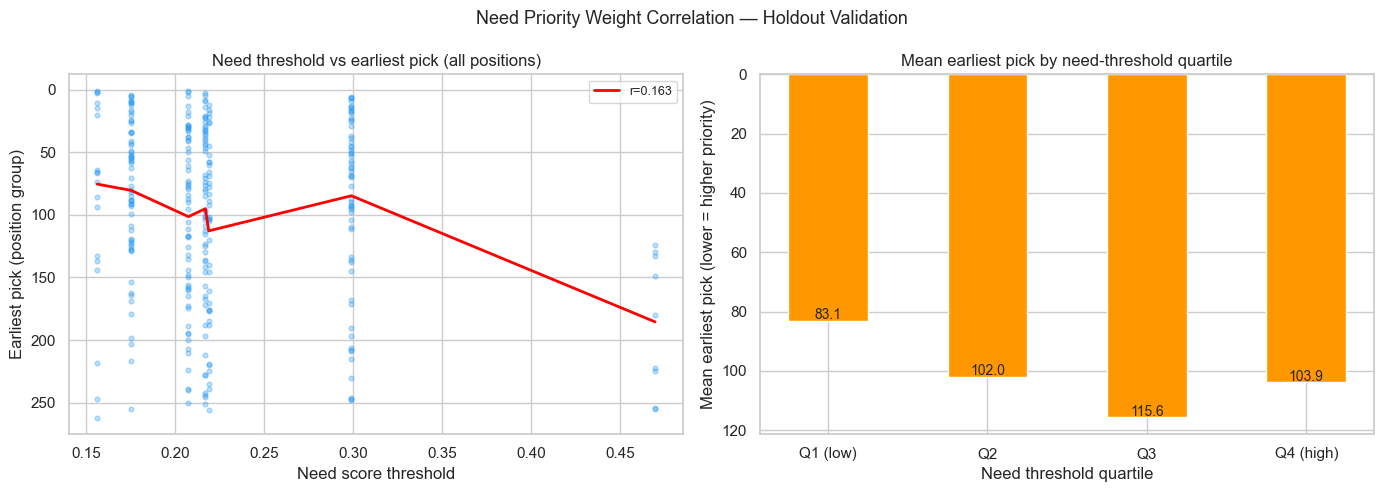

In [ ]:
# Validates that teams with high unit-weakness z-scores (need scores above threshold)
# actually receive higher-ranked picks at the corresponding position.
from statsmodels.nonparametric.smoothers_lowess import lowess

cfg        = load_constraint_config(selected_artifact_dir) or {}
thresholds = cfg.get("need_score_thresholds", {})
hold_df    = load_holdout_board(selected_artifact_dir)

if hold_df is None:
    print("No holdout board available.")
elif not thresholds:
    print("No need_score_thresholds in model.")
else:
    hold_df = hold_df.copy()
    hold_df["pick_rank"] = hold_df.groupby(["season", "draft_team", "position_group"])["pick"].rank()

    need_rows = []
    for pos_grp, thresh in thresholds.items():
        sub = hold_df[hold_df["position_group"] == pos_grp]
        earliest = sub.groupby(["season", "draft_team"])["pick"].min().reset_index(name="earliest_pick")
        earliest["position_group"] = pos_grp
        earliest["threshold"] = thresh
        need_rows.append(earliest)

    need_df = pd.concat(need_rows, ignore_index=True)
    r_global = need_df[["threshold", "earliest_pick"]].corr().iloc[0, 1]
    print(f"Global r (need_threshold vs earliest pick at position): {r_global:.3f}")

    by_pos = (
        need_df.groupby("position_group")
        .apply(lambda g: g[["threshold", "earliest_pick"]].corr().iloc[0, 1])
        .rename("r(threshold, earliest_pick)")
        .to_frame()
    )
    print("\n=== Need threshold x earliest pick correlation by position ===")
    display(
        by_pos.style
        .background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)
        .format("{:.3f}")
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    valid = need_df[["threshold", "earliest_pick"]].dropna()
    ax.scatter(valid["threshold"], valid["earliest_pick"], alpha=0.3, s=12, color="#2196F3")
    if len(valid) > 10:
        trend = lowess(valid["earliest_pick"].values, valid["threshold"].values, frac=0.5)
        ax.plot(trend[:, 0], trend[:, 1], color="red", linewidth=2, label=f"r={r_global:.3f}")
    ax.set_xlabel("Need score threshold")
    ax.set_ylabel("Earliest pick (position group)")
    ax.set_title("Need threshold vs earliest pick (all positions)")
    ax.legend(fontsize=9)
    ax.invert_yaxis()

    ax = axes[1]
    need_df["threshold_quartile"] = pd.qcut(
        need_df["threshold"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
    )
    q_means = need_df.groupby("threshold_quartile", observed=True)["earliest_pick"].mean()
    bars = ax.bar(q_means.index.astype(str), q_means.values, color="#FF9800", width=0.5)
    for bar, val in zip(bars, q_means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10)
    ax.set_xlabel("Need threshold quartile")
    ax.set_ylabel("Mean earliest pick (lower = higher priority)")
    ax.set_title("Mean earliest pick by need-threshold quartile")
    ax.invert_yaxis()

    plt.suptitle("Need Priority Weight Correlation — Holdout Validation", fontsize=13)
    plt.tight_layout()
    plt.show()

## CV vs Holdout Gap

C:\Users\Areen\AppData\Local\Temp\ipykernel_8948\1740213346.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(


=== Split summary ===
  Calibration (2000–2020)  n= 5434
  Holdout     (2021–2022)  n=  530


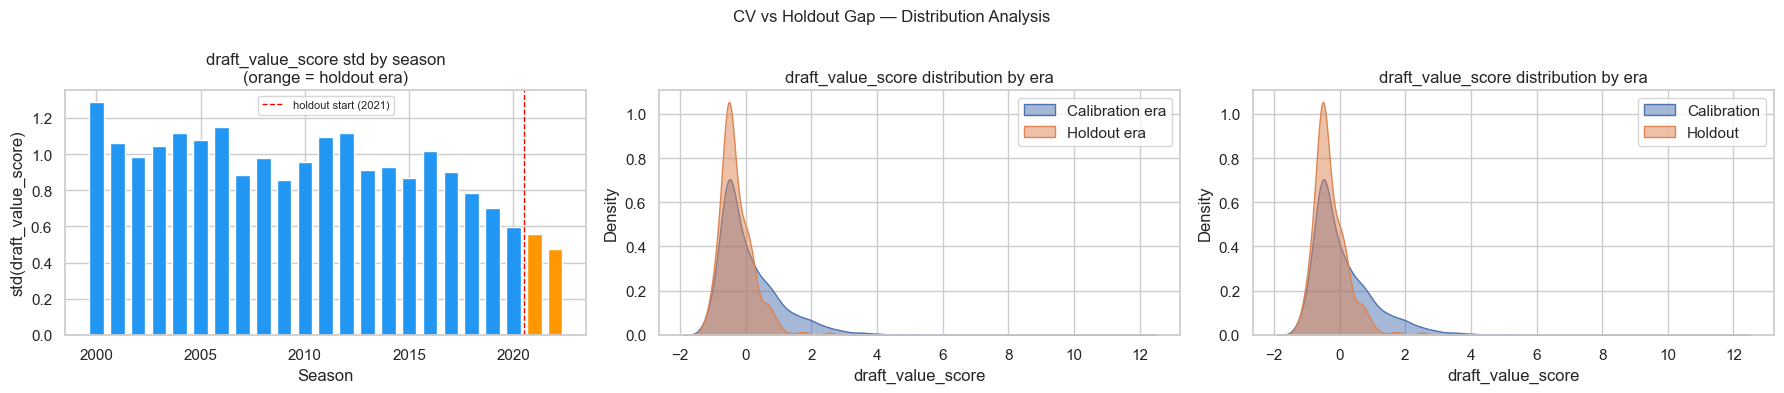


=== Season overlap check ===
  Clean split.
  Calibration seasons : [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)] (last 5 shown)
  Holdout seasons     : [np.int64(2021), np.int64(2022)]


In [ ]:
cal_df  = load_feature_data(selected_artifact_dir)
hold_df = load_holdout_board(selected_artifact_dir)
meta    = load_metadata(selected_artifact_dir) or {}

val_col       = "draft_value_score"
season_col    = "season"
cal_range     = meta.get("calibration_year_range", [2000, 2020])
holdout_start = meta.get("validation", {}).get("holdout_years", [2021])[0]

if cal_df is None:
    print("No calibration data available.")
else:
    combined = pd.concat(
        [d for d in [cal_df, hold_df] if d is not None], ignore_index=True
    )

    print("=== Split summary ===")
    print(f"  Calibration ({cal_range[0]}–{cal_range[1]})  n={len(cal_df):>5}")
    if hold_df is not None:
        h_range = f"{hold_df[season_col].min()}–{hold_df[season_col].max()}"
        print(f"  Holdout     ({h_range})  n={len(hold_df):>5}")
    else:
        print("  Holdout     (—)  n=    0")

    cal_era  = combined[combined[season_col] < holdout_start]
    hold_era = combined[combined[season_col] >= holdout_start]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    by_year = combined.groupby(season_col)[val_col].std()
    colors = ["#FF9800" if s >= holdout_start else "#2196F3" for s in by_year.index]
    ax.bar(by_year.index, by_year.values, color=colors, width=0.7)
    ax.axvline(holdout_start - 0.5, color="red", linestyle="--", linewidth=1,
               label=f"holdout start ({holdout_start})")
    ax.set_title(f"{val_col} std by season\n(orange = holdout era)")
    ax.set_xlabel("Season")
    ax.set_ylabel(f"std({val_col})")
    ax.legend(fontsize=8)

    ax = axes[1]
    sns.kdeplot(data=cal_era,  x=val_col, label="Calibration era", fill=True, alpha=0.5, ax=ax)
    if not hold_era.empty:
        sns.kdeplot(data=hold_era, x=val_col, label="Holdout era", fill=True, alpha=0.5, ax=ax)
    ax.set_title(f"{val_col} distribution by era")
    ax.set_xlabel(val_col)
    ax.legend()

    ax = axes[2]
    sns.kdeplot(data=cal_era,  x=val_col, label="Calibration", fill=True, alpha=0.5, ax=ax)
    if not hold_era.empty:
        sns.kdeplot(data=hold_era, x=val_col, label="Holdout", fill=True, alpha=0.5, ax=ax)
    ax.set_title("draft_value_score distribution by era")
    ax.set_xlabel("draft_value_score")
    ax.legend()

    plt.suptitle("CV vs Holdout Gap — Distribution Analysis", fontsize=12)
    plt.tight_layout()
    plt.show()

    if hold_df is not None:
        cal_seasons  = set(cal_df[season_col].unique())
        hold_seasons = set(hold_df[season_col].unique())
        overlap = cal_seasons & hold_seasons
        print("\n=== Season overlap check ===")
        if overlap:
            print(f"  WARNING — overlapping seasons: {sorted(overlap)}")
        else:
            print("  Clean split.")
            print(f"  Calibration seasons : {sorted(cal_seasons)[-5:]} (last 5 shown)")
            print(f"  Holdout seasons     : {sorted(hold_seasons)}")

## ADP Surplus Analysis

C:\Users\Areen\AppData\Local\Temp\ipykernel_8948\2375018639.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_df = pd.concat([d for d in [cal_df, hold_df] if d is not None], ignore_index=True)


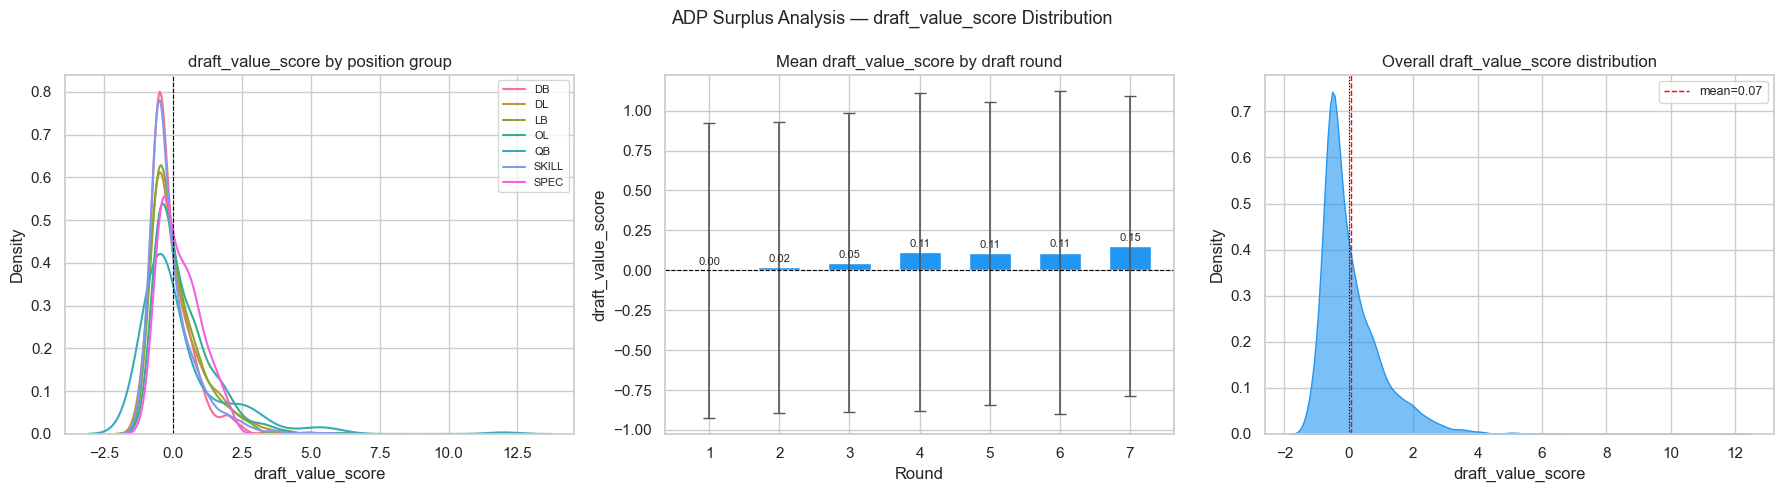


=== Top 10 picks by draft_value_score (holdout) ===


,player_name,season,draft_team,position_group,round,pick,draft_value_score,car_av
0,Brock Purdy,2022,SFO,QB,7,262,2.628,44.0
1,Amon-Ra St. Brown,2021,DET,SKILL,4,112,2.460,57.0
2,Trey Smith,2021,KAN,OL,6,226,1.829,36.0
3,Jonathon Cooper,2021,DEN,DL,7,239,1.747,32.0
4,Rasheed Walker,2022,GNB,OL,7,249,1.526,29.0
5,Kyren Williams,2022,LAR,SKILL,5,164,1.190,31.0
6,Talanoa Hufanga,2021,SFO,DB,5,180,1.067,29.0
7,Dan Moore,2021,PIT,OL,4,128,1.010,32.0
8,Creed Humphrey,2021,KAN,OL,2,63,0.992,51.0
9,Isiah Pacheco,2022,KAN,SKILL,7,251,0.939,21.0



=== Bottom 10 picks by draft_value_score (holdout) ===


,player_name,season,draft_team,position_group,round,pick,draft_value_score,car_av
0,Caleb Farley,2021,TEN,DB,1,22,-1.327,2.0
1,Payton Turner,2021,NOR,DL,1,28,-1.294,3.0
2,Trey Lance,2021,SFO,QB,1,3,-1.194,6.0
3,Kadarius Toney,2021,NYG,SKILL,1,20,-1.161,7.0
4,Treylon Burks,2022,TEN,SKILL,1,18,-1.161,7.0
5,Alex Leatherwood,2021,LVR,OL,1,17,-1.127,8.0
6,Kenyon Green,2022,HOU,OL,1,15,-1.127,8.0
7,Kaiir Elam,2022,BUF,DB,1,23,-1.094,9.0
8,Kelvin Joseph,2021,DAL,DB,2,44,-1.070,2.0
9,Phidarian Mathis,2022,WAS,DL,2,47,-1.070,2.0


In [ ]:
# Distribution of value_over_adp (draft_value_score) by position group,
# by round, and overall KDE. Includes top/bottom 10 picks for case-study verification.

hold_df = load_holdout_board(selected_artifact_dir)
cal_df  = load_feature_data(selected_artifact_dir)
val_col = "draft_value_score"

all_df = pd.concat([d for d in [cal_df, hold_df] if d is not None], ignore_index=True)

if all_df.empty or val_col not in all_df.columns:
    print(f"No data or '{val_col}' column not available.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    pos_groups = sorted(all_df["position_group"].dropna().unique())
    palette = sns.color_palette("husl", len(pos_groups))
    for pos, color in zip(pos_groups, palette):
        sub = all_df[all_df["position_group"] == pos][val_col].dropna()
        if len(sub) > 5:
            sns.kdeplot(data=sub, label=pos, fill=False, ax=ax, color=color, linewidth=1.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{val_col} by position group")
    ax.set_xlabel(val_col)
    ax.legend(fontsize=8)

    ax = axes[1]
    all_df["round"] = all_df["round"].astype(int)
    round_means = all_df.groupby("round")[val_col].mean().sort_index()
    round_stds  = all_df.groupby("round")[val_col].std().sort_index()
    bars = ax.bar(round_means.index, round_means.values, color="#2196F3", width=0.6)
    ax.errorbar(round_means.index, round_means.values, yerr=round_stds.values,
                fmt="none", color="#555", linewidth=1.2, capsize=4)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    for bar, val in zip(bars, round_means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"Mean {val_col} by draft round")
    ax.set_xlabel("Round")
    ax.set_ylabel(val_col)

    ax = axes[2]
    sns.kdeplot(data=all_df, x=val_col, fill=True, alpha=0.6, color="#2196F3", ax=ax)
    ax.axvline(all_df[val_col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"mean={all_df[val_col].mean():.2f}")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"Overall {val_col} distribution")
    ax.set_xlabel(val_col)
    ax.legend(fontsize=9)

    plt.suptitle("ADP Surplus Analysis — draft_value_score Distribution", fontsize=13)
    plt.tight_layout()
    plt.show()

    if hold_df is not None and val_col in hold_df.columns:
        rank_df = hold_df[
            ["player_name", "season", "draft_team", "position_group", "round", "pick", val_col, "car_av"]
        ].dropna(subset=[val_col])
        top10 = rank_df.nlargest(10, val_col)
        bot10 = rank_df.nsmallest(10, val_col)
        print("\n=== Top 10 picks by draft_value_score (holdout) ===")
        display(top10.reset_index(drop=True).style.format({val_col: "{:.3f}", "car_av": "{:.1f}"}))
        print("\n=== Bottom 10 picks by draft_value_score (holdout) ===")
        display(bot10.reset_index(drop=True).style.format({val_col: "{:.3f}", "car_av": "{:.1f}"}))

## All-Version Comparison

In [ ]:
rows = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if not meta:
        continue
    v  = meta.get("validation", {})
    hm = _compute_holdout_metrics(run)
    rows.append({
        "version":                   meta.get("version", run.name),
        "holdout_r2":                hm.get("holdout_r2"),
        "holdout_rmse":              hm.get("holdout_rmse"),
        "holdout_mae":               hm.get("holdout_mae"),
        "baseline_rmse":             hm.get("baseline_rmse"),
        "mean_value_over_adp_top10": v.get("optimizer_score"),
        "adp_baseline_score":        v.get("adp_baseline_score"),
        "holdout_picks":             v.get("holdout_picks"),
        "n_pick_slots":              meta.get("n_pick_slots"),
        "solver":                    meta.get("solver"),
    })

prog = pd.DataFrame(rows)

if len(prog) > 1:
    v1_rmse = prog.loc[prog["version"] == "v1", "holdout_rmse"].values[0]
    prog["delta_rmse_vs_v1"] = prog["holdout_rmse"] - v1_rmse

baseline_rmse = prog["baseline_rmse"].iloc[0]
prog["pct_beat_baseline"] = (
    (1 - prog["holdout_rmse"] / baseline_rmse) * 100 if baseline_rmse else None
)
adp_base = prog["adp_baseline_score"].iloc[0]
prog["surplus_vs_adp"] = prog["mean_value_over_adp_top10"] - adp_base

display_cols = [
    "version", "holdout_r2", "holdout_rmse", "holdout_mae",
    "pct_beat_baseline", "mean_value_over_adp_top10", "surplus_vs_adp",
]
if "delta_rmse_vs_v1" in prog.columns:
    display_cols.insert(4, "delta_rmse_vs_v1")

fmt = {
    "holdout_r2":                "{:.4f}",
    "holdout_rmse":              "{:.4f}",
    "holdout_mae":               "{:.4f}",
    "pct_beat_baseline":         "{:.1f}%",
    "mean_value_over_adp_top10": "{:.4f}",
    "surplus_vs_adp":            "{:+.4f}",
}
if "delta_rmse_vs_v1" in prog.columns:
    fmt["delta_rmse_vs_v1"] = "{:+.4f}"

grad_r2   = [c for c in ["holdout_r2", "pct_beat_baseline"] if c in display_cols]
grad_rmse = [c for c in ["holdout_rmse", "holdout_mae"] if c in display_cols]

styled = prog[display_cols].style.format(fmt)
if grad_rmse:
    styled = styled.background_gradient(subset=grad_rmse, cmap="RdYlGn_r", axis=0)
if grad_r2:
    styled = styled.background_gradient(subset=grad_r2, cmap="RdYlGn", axis=0)
display(styled)

if len(prog) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    ax = axes[0]
    bars = ax.bar(prog["version"], prog["holdout_rmse"], color="#2196F3", width=0.5)
    ax.axhline(baseline_rmse, color="red", linestyle="--", linewidth=1,
               label=f"baseline ({baseline_rmse:.2f})")
    for bar, val in zip(bars, prog["holdout_rmse"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title("Holdout RMSE by version")
    ax.set_ylabel("RMSE (car_av)")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(prog["version"], prog["holdout_r2"], marker="o", color="#4CAF50", linewidth=2)
    for _, row in prog.iterrows():
        ax.annotate(f"{row['holdout_r2']:.3f}", (row["version"], row["holdout_r2"]),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax.set_title("R² progression")
    ax.set_ylabel("R²")

    ax = axes[2]
    bars = ax.bar(prog["version"], prog["surplus_vs_adp"], color="#FF9800", width=0.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    for bar, val in zip(bars, prog["surplus_vs_adp"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + (0.1 if val >= 0 else -0.3),
                f"{val:+.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_title("Optimizer top-10 surplus vs ADP baseline")
    ax.set_ylabel("Surplus (car_av units)")

    plt.suptitle("All-Version Comparison — Draft Optimizer", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Only one version found — skipping progression chart.")

,version,holdout_r2,holdout_rmse,holdout_mae,pct_beat_baseline,mean_value_over_adp_top10,surplus_vs_adp
0,v1,-1.2193,17.3738,13.1654,-49.0%,14.8676,+12.7242


Only one version found — skipping progression chart.
